# SSI Method Validation (Synthetic Ground Truth)

This notebook validates the SSI + null-bootstrap pipeline with synthetic data.

We test:
1. **Example cell**: null SSI distribution vs real SSI.
2. **Calibration under null**: p-values should be close to uniform.
3. **Power with true place field**: detection rate should increase with field amplitude.


In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO_ROOT = Path('..').resolve()
sys.path.insert(0, str(REPO_ROOT / 'src'))

from placefields import (
    TrialInfo,
    RatemapConfig,
    build_ratemap_from_trials,
    NullBootstrapConfig,
    simulate_null_fr_s_txrep,
    compute_condition_occupancy,
    ssi_observed_by_condition,
    ssi_null_by_condition,
    empirical_pvalue_from_null,
)

plt.style.use('default')

In [2]:
# ---- Global simulation parameters ----
FREQ_HZ = 100.0
N_LAPS = 20
LAP_LEN = 350
N_COND = 2
XBIN_EDGES = np.linspace(0, 100, 101)   # 100 bins before trimming
XBIN_REM = 10                            # -> 80 bins after trimming
SMOOTH_SIGMA = 3.0
MIN_SPEED = 2.0

NULL_METHOD = 'circular_shift'           # 'random' | 'poisson' | 'circular_shift'
NB_REP = 300

BASELINE_HZ = 5.0
FIELD_CENTER = 55.0
FIELD_SIGMA = 5.0

ALPHA = 0.05
print('Configured with null method:', NULL_METHOD)

Configured with null method: circular_shift


In [3]:
def make_synthetic_session(*, n_laps=N_LAPS, lap_len=LAP_LEN, n_cond=N_COND, occupancy_mode='uniform', rng=None):
    if rng is None:
        rng = np.random.default_rng()

    n_samples = n_laps * lap_len
    x = np.full(n_samples, np.nan, dtype=float)
    speed = np.full(n_samples, 20.0, dtype=float)
    cond_sample = np.full(n_samples, -1, dtype=np.int64)
    trials = []

    for lap in range(n_laps):
        s = lap * lap_len
        e = (lap + 1) * lap_len
        t = np.linspace(0, 1, lap_len, endpoint=False)

        if occupancy_mode == 'uniform':
            base = 100.0 * t
        elif occupancy_mode == 'biased':
            # Slower in center/edges depending on transform -> non-uniform occupancy.
            base = 100.0 * ((np.sin((t - 0.5) * np.pi) + 1.0) / 2.0)
        else:
            raise ValueError("occupancy_mode must be 'uniform' or 'biased'")

        pos = np.clip(base + rng.normal(0.0, 0.5, size=lap_len), 0.0, 100.0)
        x[s:e] = pos

        condway = 1 + (lap % n_cond)
        cond_sample[s:e] = condway
        trials.append(
            TrialInfo(
                trial_index=lap,
                cond=condway,
                wb='W',
                condway=condway,
                start_idx_0b=s,
                stop_idx_0b_exclusive=e,
            )
        )

    return x, speed, trials, cond_sample


def rate_profile(x, *, baseline_hz=BASELINE_HZ, peak_hz=0.0, center=FIELD_CENTER, sigma=FIELD_SIGMA):
    return baseline_hz + peak_hz * np.exp(-0.5 * ((x - center) / sigma) ** 2)


def simulate_spike_indices(rate_hz_t, *, freq_hz=FREQ_HZ, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    lam = np.clip(np.asarray(rate_hz_t, dtype=float) / float(freq_hz), 0.0, None)
    counts = rng.poisson(lam)
    return np.repeat(np.arange(lam.size, dtype=np.int64), counts.astype(np.int64))


def run_one_sim(
    *,
    peak_hz,
    null_method=NULL_METHOD,
    nb_rep=NB_REP,
    occupancy_mode='biased',
    seed=0,
):
    rng = np.random.default_rng(seed)
    x, speed, trials, cond_sample = make_synthetic_session(occupancy_mode=occupancy_mode, rng=rng)

    rate_t = rate_profile(x, peak_hz=float(peak_hz))
    spk_idx = simulate_spike_indices(rate_t, rng=rng)
    spk_cid = np.ones(spk_idx.size, dtype=np.int64)
    cell_ids = np.array([1], dtype=np.int64)

    rmap_cfg = RatemapConfig(
        freq_hz=FREQ_HZ,
        smooth_sigma_bins=SMOOTH_SIGMA,
        xbin_rem=XBIN_REM,
        min_speed=MIN_SPEED,
    )
    pack = build_ratemap_from_trials(
        position_x=x,
        spike_indices_0b=spk_idx,
        spike_cell_ids=spk_cid,
        cell_ids=cell_ids,
        trials=trials,
        xbin_edges=XBIN_EDGES,
        cfg=rmap_cfg,
        speed=speed,
    )

    sample_keep = np.isfinite(x) & np.isfinite(speed) & (speed >= MIN_SPEED)
    null_cfg = NullBootstrapConfig(method=null_method, nb_rep=int(nb_rep), seed=int(seed) + 1000)
    fr_s_txrep = simulate_null_fr_s_txrep(
        position_x=x,
        spike_indices_cell_0b=spk_idx,
        trials=pack.trial_info,
        xbin_edges=pack.xbin_edges,
        dwell_s_tx_x=pack.dwell_s_tx_x,
        smooth_sigma_bins=SMOOTH_SIGMA,
        cfg=null_cfg,
        valid_sample_mask=sample_keep,
    )

    occ_cx = compute_condition_occupancy(pack.dwell_tx_x, pack.idcond_t, pack.nb_cond)
    ssi_obs = ssi_observed_by_condition(pack.fr_s_cx_ux[0], occ_cx)
    ssi_null = ssi_null_by_condition(fr_s_txrep, pack.idcond_t, pack.nb_cond, occ_cx)
    pvals = empirical_pvalue_from_null(ssi_obs, ssi_null, alternative='greater', add_one=True)

    return {
        'pack': pack,
        'occ_cx': occ_cx,
        'ssi_obs': ssi_obs,
        'ssi_null': ssi_null,
        'pvals': pvals,
        'n_spikes': int(spk_idx.size),
        'rate_t': rate_t,
    }


spikes: 384
SSI real per condition: [0.1807 0.0532]
p-value per condition : [0.0033 0.4153]


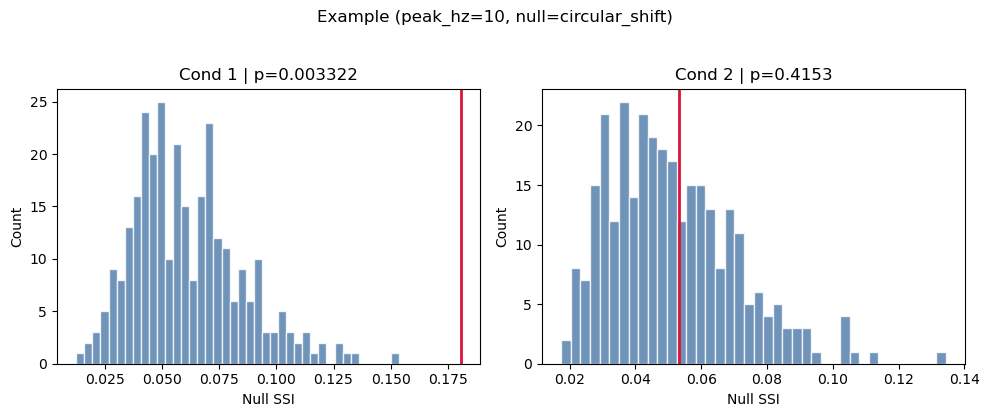

In [4]:
# --- One example with true place field ---
example = run_one_sim(peak_hz=10.0, null_method=NULL_METHOD, nb_rep=NB_REP, occupancy_mode='biased', seed=1)
print('spikes:', example['n_spikes'])
print('SSI real per condition:', np.round(example['ssi_obs'], 4))
print('p-value per condition :', np.round(example['pvals'], 4))

n_cond = example['ssi_obs'].size
fig, axes = plt.subplots(1, n_cond, figsize=(5 * n_cond, 4), squeeze=False)
axes = axes.ravel()
for c in range(n_cond):
    nd = example['ssi_null'][c]
    nd = nd[np.isfinite(nd)]
    axes[c].hist(nd, bins=40, color='#4c78a8', alpha=0.8, edgecolor='white')
    axes[c].axvline(example['ssi_obs'][c], color='crimson', linewidth=2)
    axes[c].set_title(f'Cond {c+1} | p={example["pvals"][c]:.4g}')
    axes[c].set_xlabel('Null SSI')
    axes[c].set_ylabel('Count')
fig.suptitle(f'Example (peak_hz=10, null={NULL_METHOD})', y=1.03)
fig.tight_layout()
plt.show()

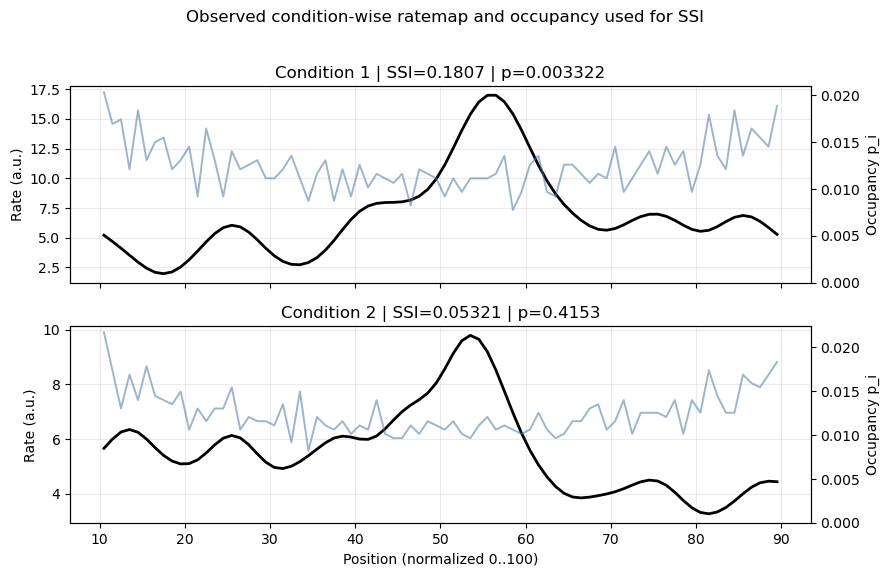

In [5]:
# --- Plot observed rate maps used for SSI (per condition) ---
fr_cx = example['pack'].fr_s_cx_ux[0]      # shape: (n_cond, n_bins)
x_cent = example['pack'].xbin_centers
occ = example['occ_cx']

n_cond = fr_cx.shape[0]
fig, axes = plt.subplots(n_cond, 1, figsize=(9, 2.8 * n_cond), sharex=True, squeeze=False)
axes = axes.ravel()

for c in range(n_cond):
    ax = axes[c]
    ax.plot(x_cent, fr_cx[c], color='black', linewidth=2.0, label='Observed fr_s_cx')
    ax.set_ylabel('Rate (a.u.)')
    ax.set_title(
        f'Condition {c+1} | SSI={example["ssi_obs"][c]:.4g} | p={example["pvals"][c]:.4g}'
    )
    ax.grid(alpha=0.25)

    # Secondary axis to visualize occupancy profile used in SSI weighting
    ax2 = ax.twinx()
    ax2.plot(x_cent, occ[c], color='#4c78a8', alpha=0.55, linewidth=1.4, label='Occupancy p_i')
    ax2.set_ylabel('Occupancy p_i')
    ax2.set_ylim(bottom=0)

axes[-1].set_xlabel('Position (normalized 0..100)')
fig.suptitle('Observed condition-wise ratemap and occupancy used for SSI', y=1.02)
fig.tight_layout()
plt.show()

n valid p-values: 60
False positive rate at alpha=0.05: 0.000


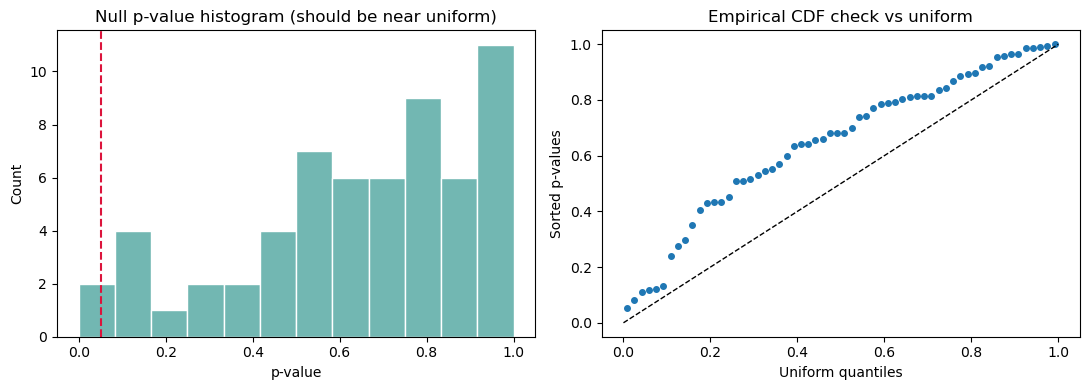

In [6]:
# --- Calibration under null (peak_hz=0) ---
N_SIM_NULL = 60
pvals_null = []

for i in range(N_SIM_NULL):
    out = run_one_sim(
        peak_hz=0.0,
        null_method=NULL_METHOD,
        nb_rep=NB_REP,
        occupancy_mode='biased',
        seed=10000 + i,
    )
    # Use condition 1 for summary; you can pool both conditions if preferred.
    pvals_null.append(out['pvals'][0])

pvals_null = np.asarray(pvals_null, dtype=float)
pvals_null = pvals_null[np.isfinite(pvals_null)]
fp_rate = np.mean(pvals_null < ALPHA)
print(f'n valid p-values: {pvals_null.size}')
print(f'False positive rate at alpha={ALPHA}: {fp_rate:.3f}')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(pvals_null, bins=12, range=(0, 1), color='#72b7b2', edgecolor='white')
axes[0].axvline(ALPHA, color='crimson', linestyle='--', linewidth=1.5)
axes[0].set_title('Null p-value histogram (should be near uniform)')
axes[0].set_xlabel('p-value')
axes[0].set_ylabel('Count')

p_sorted = np.sort(pvals_null)
u = (np.arange(1, p_sorted.size + 1) - 0.5) / p_sorted.size
axes[1].plot(u, p_sorted, 'o', markersize=4)
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1)
axes[1].set_title('Empirical CDF check vs uniform')
axes[1].set_xlabel('Uniform quantiles')
axes[1].set_ylabel('Sorted p-values')

fig.tight_layout()
plt.show()

In [7]:
# --- Power curve: increase field amplitude and monitor detection probability ---
N_SIM_POWER = 40
PEAKS = [0.0, 2.0, 4.0, 6.0, 8.0, 12.0]

rows = []
seed0 = 20000
for peak in PEAKS:
    pvals = []
    ssi_vals = []
    for i in range(N_SIM_POWER):
        out = run_one_sim(
            peak_hz=peak,
            null_method=NULL_METHOD,
            nb_rep=NB_REP,
            occupancy_mode='biased',
            seed=seed0 + int(peak * 1000) + i,
        )
        pvals.append(out['pvals'][0])
        ssi_vals.append(out['ssi_obs'][0])

    pvals = np.asarray(pvals, dtype=float)
    ssi_vals = np.asarray(ssi_vals, dtype=float)
    ok = np.isfinite(pvals)
    rows.append({
        'peak_hz': peak,
        'n': int(np.sum(ok)),
        'detect_rate_alpha05': float(np.mean(pvals[ok] < ALPHA)) if np.any(ok) else np.nan,
        'pval_median': float(np.nanmedian(pvals[ok])) if np.any(ok) else np.nan,
        'ssi_median': float(np.nanmedian(ssi_vals)),
    })

power_df = pd.DataFrame(rows)
power_df

,peak_hz,n,detect_rate_alpha05,pval_median,ssi_median
0,0.0,40,0.075,0.681063,0.042369
1,2.0,40,0.050,0.669435,0.041567
2,4.0,40,0.150,0.274086,0.057000
3,6.0,40,0.400,0.117940,0.073526
4,8.0,40,0.525,0.046512,0.085486
5,12.0,40,0.925,0.003322,0.166916


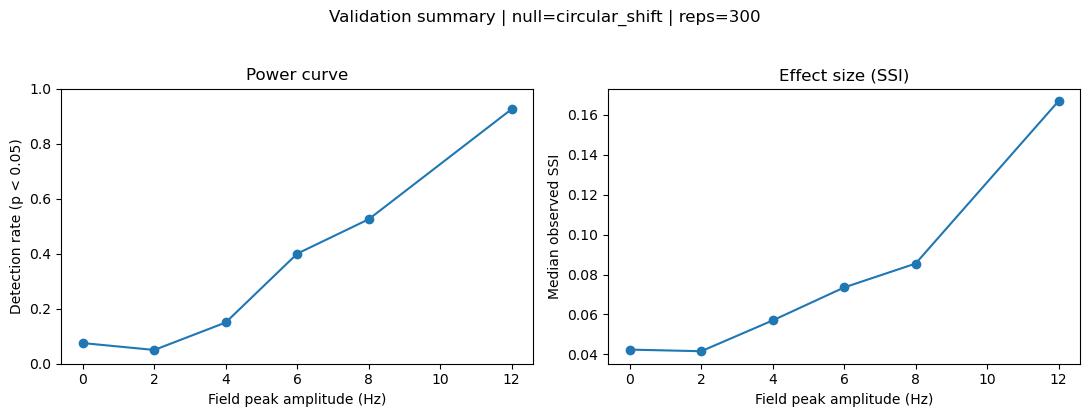

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(power_df['peak_hz'], power_df['detect_rate_alpha05'], marker='o')
axes[0].set_xlabel('Field peak amplitude (Hz)')
axes[0].set_ylabel(f'Detection rate (p < {ALPHA})')
axes[0].set_ylim(0, 1)
axes[0].set_title('Power curve')

axes[1].plot(power_df['peak_hz'], power_df['ssi_median'], marker='o')
axes[1].set_xlabel('Field peak amplitude (Hz)')
axes[1].set_ylabel('Median observed SSI')
axes[1].set_title('Effect size (SSI)')

fig.suptitle(f'Validation summary | null={NULL_METHOD} | reps={NB_REP}', y=1.03)
fig.tight_layout()
plt.show()

## Notes

- If calibration is poor (too many false positives), increase `NB_REP`, laps, or compare with `circular_shift` (often more conservative).
- To compare null models, rerun with `NULL_METHOD='random'` and `'circular_shift'`.
- You can also stress-test occupancy dependence by switching `occupancy_mode` between `'uniform'` and `'biased'`.